# DA-06. Recovery & Idempotency 검증

## 1. 분석 목적

외부 Digital Asset 거래에서 요청을 전송한 뒤 응답을 확정하지 못한 `SENT_UNKNOWN` 상태가 발생했을 때,
단순 재전송이 아니라 기존 실행 결과를 먼저 조회하고 복구해야 하는 이유를 검증한다.

본 분석은 두 종류의 Evidence를 명확히 분리한다.

1. **Observed Evidence**
   - Ethereum 실제 거래의 Transaction Hash
   - Sender + Nonce
   - Execution / Receipt 상태
   - 동일 거래를 식별할 수 있는 외부 실행 식별자의 존재

2. **Controlled Recovery Experiment**
   - 실제 Ethereum Transaction을 대상으로 응답 유실(SENT_UNKNOWN)을 주입
   - 동일 요청의 재호출 상황을 재현
   - `NAIVE_RESEND`와 `RECONCILIATION_FIRST` 전략을 비교

Ethereum 공개 체인 데이터만으로 실제 네트워크 응답 유실률이나 Retry 발생률을 추정하지 않는다.

## 2. 핵심 검증 질문

### Q1
실행된 Transaction을 다시 식별할 수 있는 안정적인 External Reference가 존재하는가?

### Q2
`SENT_UNKNOWN` 발생 직후 동일 Business Request를 새 Transaction으로 재생성하면
중복 외부 실행 가능성이 발생하는가?

### Q3
기존 Transaction Hash / External Reference를 먼저 조회하는
`RECONCILIATION_FIRST` 전략은 중복 제출 없이 상태를 복구할 수 있는가?

### Q4
동일 `idempotency_key`에 대해 Outbound Submission이 최대 1회라는
Runtime Invariant를 강제할 수 있는가?

## 3. 검증 기준

핵심 Runtime Invariant는 다음과 같다.

- 동일 `idempotency_key` → 최초 Outbound Submission 최대 1회
- `SENT_UNKNOWN` → 즉시 자동 재전송 금지
- 기존 `external_transaction_id` 조회 우선
- 조회 성공 → 기존 Transaction 상태로 수렴
- 상태 확인 불가 → `RECONCILIATION_REQUIRED`
- Amount / Asset / Destination 불일치 → 자동 완료 금지
- 중복 External Effect → 0
- 중복 State Transition → 0

최종 목적은 Retry 자체를 최적화하는 것이 아니라,

**동일 요청 식별 → 기존 실행 조회 → 중복 실행 방지 → 최종 상태 수렴**

구조를 FPG Runtime Contract로 고정하는 것이다.

In [1]:
# 01. 라이브러리 및 데이터 로드

from pathlib import Path

import numpy as np
import pandas as pd

DATA_PATH = Path(
    r"C:\Users\user\Downloads\da_master_transaction_sample_73410 - 복사본.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"전체 거래 수: {len(df):,}")
print(f"전체 컬럼 수: {len(df.columns):,}")

print("\n컬럼 목록")
for col in df.columns:
    print(f"- {col}")


# 02. DA-06 핵심 컬럼 탐색

column_candidates = {
    "transaction_hash": [
        "transaction_hash",
        "hash"
    ],
    "from_address": [
        "from_address",
        "from"
    ],
    "nonce": [
        "nonce"
    ],
    "receipt_status": [
        "receipt_status",
        "status",
        "execution_status"
    ],
    "block_number": [
        "block_number"
    ],
    "block_timestamp": [
        "block_timestamp"
    ]
}

resolved_columns = {}

for logical_name, candidates in column_candidates.items():
    resolved_columns[logical_name] = next(
        (
            col
            for col in candidates
            if col in df.columns
        ),
        None
    )

resolved_df = (
    pd.DataFrame(
        resolved_columns.items(),
        columns=["logical_field", "actual_column"]
    )
)

print("\nDA-06 사용 가능 컬럼")
display(resolved_df)


# 03. 핵심 식별자 결측 확인

quality_rows = []

for logical_name, actual_column in resolved_columns.items():

    if actual_column is None:
        quality_rows.append({
            "field": logical_name,
            "column": None,
            "missing_count": None,
            "missing_ratio": None
        })

    else:
        missing_count = df[actual_column].isna().sum()

        quality_rows.append({
            "field": logical_name,
            "column": actual_column,
            "missing_count": missing_count,
            "missing_ratio": missing_count / len(df)
        })

quality_df = pd.DataFrame(quality_rows)

display(quality_df)

전체 거래 수: 73,410
전체 컬럼 수: 13

컬럼 목록
- block_number
- block_timestamp
- transaction_hash
- transaction_type
- from_address
- to_address
- value
- value_lossless
- gas
- gas_price
- receipt_status
- gas_used
- contract_address

DA-06 사용 가능 컬럼


,logical_field,actual_column
0,transaction_hash,transaction_hash
1,from_address,from_address
2,nonce,None
3,receipt_status,receipt_status
4,block_number,block_number
5,block_timestamp,block_timestamp


,field,column,missing_count,missing_ratio
0,transaction_hash,transaction_hash,0.0,0.0
1,from_address,from_address,0.0,0.0
2,nonce,None,NaN,NaN
3,receipt_status,receipt_status,0.0,0.0
4,block_number,block_number,0.0,0.0
5,block_timestamp,block_timestamp,0.0,0.0


## 4. External Transaction Reference 검증

본 데이터에는 Ethereum `nonce`가 포함되어 있지 않다.

따라서 `(from_address, nonce)` 조합을 이용한 중복 Transaction 식별은
본 분석에서 직접 검증할 수 없다.

대신 실제 외부 실행 이후 생성되는 `transaction_hash`를
`external_transaction_id`의 관측 가능한 대리값으로 사용한다.

검증 항목은 다음과 같다.

1. `transaction_hash` 결측 여부
2. `transaction_hash` 중복 여부
3. Transaction Hash와 실제 Receipt 상태 연결 가능 여부

여기서 중요한 구분은 다음과 같다.

- `idempotency_key`
  - FPG 내부 Business Request 식별자
  - 외부 전송 전에 생성되어야 함

- `external_transaction_id`
  - 실제 외부 실행 식별자
  - Ethereum에서는 `transaction_hash`가 해당 역할을 수행할 수 있음

따라서 FPG는 두 식별자를 분리해서 보존해야 한다.

`idempotency_key → external_transaction_id → execution_status`

In [3]:
# 04. Transaction Hash 유일성 및 Receipt 연결 검증

tx_hash_col = resolved_columns["transaction_hash"]
status_col = resolved_columns["receipt_status"]

tx_total = len(df)

tx_hash_missing = df[tx_hash_col].isna().sum()
tx_hash_unique = df[tx_hash_col].nunique(dropna=True)
tx_hash_duplicate_rows = df.duplicated(
    subset=[tx_hash_col],
    keep=False
).sum()

tx_hash_duplicate_keys = (
    df.loc[
        df.duplicated(subset=[tx_hash_col], keep=False),
        tx_hash_col
    ]
    .nunique()
)

reference_summary = pd.DataFrame({
    "metric": [
        "전체 Transaction",
        "Transaction Hash 결측",
        "고유 Transaction Hash",
        "중복 Hash 포함 행",
        "중복 Hash Key"
    ],
    "value": [
        tx_total,
        tx_hash_missing,
        tx_hash_unique,
        tx_hash_duplicate_rows,
        tx_hash_duplicate_keys
    ]
})

display(reference_summary)


# 05. Receipt Status 분포

receipt_summary = (
    df[status_col]
    .value_counts(dropna=False)
    .rename_axis("receipt_status")
    .reset_index(name="count")
)

receipt_summary["ratio"] = (
    receipt_summary["count"] / len(df)
)

display(receipt_summary)


# 06. Transaction Hash → Receipt Status 연결 완전성

recovery_reference_df = (
    df[
        [
            "transaction_hash",
            "block_number",
            "block_timestamp",
            "receipt_status"
        ]
    ]
    .copy()
)

recovery_reference_df["reference_complete"] = (
    recovery_reference_df["transaction_hash"].notna()
    & recovery_reference_df["block_number"].notna()
    & recovery_reference_df["receipt_status"].notna()
)

reference_complete_summary = (
    recovery_reference_df["reference_complete"]
    .value_counts()
    .rename_axis("reference_complete")
    .reset_index(name="count")
)

reference_complete_summary["ratio"] = (
    reference_complete_summary["count"]
    / len(recovery_reference_df)
)

display(reference_complete_summary)

,metric,value
0,전체 Transaction,73410
1,Transaction Hash 결측,0
2,고유 Transaction Hash,73410
3,중복 Hash 포함 행,0
4,중복 Hash Key,0


,receipt_status,count,ratio
0,1,72241,0.984076
1,0,1169,0.015924


,reference_complete,count,ratio
0,True,73410,1.0


## 5. SENT_UNKNOWN Counterfactual Recovery Test

실제 데이터에는 네트워크 응답 유실 여부가 기록되어 있지 않다.

따라서 실제 `SENT_UNKNOWN 발생률`을 추정하지 않는다.

대신 관측된 73,410건 각각에 대해 다음 상황을 가정한다.

> 외부 Transaction은 이미 제출되었고 `transaction_hash`도 확보했지만,
> 이후 응답이 유실되어 FPG가 최종 실행 결과를 즉시 확정하지 못했다.

이를 `SENT_UNKNOWN_WITH_REFERENCE`로 정의한다.

두 Recovery 전략을 비교한다.

### Strategy A. NAIVE_RESEND

상태가 불명확하다는 이유로 동일 Business Request를 즉시 다시 제출한다.

- 기존 거래가 성공한 경우 중복 가치이동 위험 발생
- 기존 거래가 실패했더라도 중복 Submission 발생
- 기존 실행 결과를 확인하지 않고 새로운 외부 실행을 생성

### Strategy B. RECONCILIATION_FIRST

기존 `transaction_hash`를 이용해 Receipt를 먼저 조회한다.

- `receipt_status = 1` → 기존 실행을 FINALIZED로 복구
- `receipt_status = 0` → 기존 실행을 FAILED로 복구
- 조회 결과가 없을 때만 `RECONCILIATION_REQUIRED` 유지
- Terminal Failure 확인 후 Retry가 필요한 경우 별도의 Retry 정책으로 처리

본 실험의 핵심 평가지표는 다음과 같다.

1. Duplicate Submission Risk
2. Duplicate External Effect Risk
3. 기존 Transaction 상태 복구 가능률

In [4]:
# 07. SENT_UNKNOWN Counterfactual Recovery Test

recovery_test_df = df[
    [
        "transaction_hash",
        "receipt_status",
        "block_number",
        "block_timestamp"
    ]
].copy()

recovery_test_df["original_success"] = (
    recovery_test_df["receipt_status"] == 1
)

# 모든 Transaction에서
# "외부 제출 후 응답이 유실되었다"는 상황을 가정
recovery_test_df["sent_unknown"] = True


# 08. NAIVE_RESEND 전략

# 상태 확인 없이 새로운 외부 제출 발생
recovery_test_df["naive_resend"] = True

# 기존 요청이 이미 제출되었으므로
# 모든 건에서 duplicate submission 발생
recovery_test_df["naive_duplicate_submission"] = True

# 기존 Transaction이 성공한 경우
# 동일 요청 재전송은 중복 외부 효과 위험을 가진다
recovery_test_df["naive_duplicate_effect_risk"] = (
    recovery_test_df["original_success"]
)


# 09. RECONCILIATION_FIRST 전략

recovery_test_df["reconciliation_lookup"] = True

# 본 데이터는 모든 Transaction에
# Hash + Receipt가 존재하므로 기존 상태 복구 가능
recovery_test_df["reconciliation_recovered"] = (
    recovery_test_df["transaction_hash"].notna()
    & recovery_test_df["receipt_status"].notna()
)

# 기존 상태 확인 전 자동 재전송 금지
recovery_test_df["reconciliation_immediate_resend"] = False

recovery_test_df["reconciliation_duplicate_submission"] = False
recovery_test_df["reconciliation_duplicate_effect_risk"] = False


# 10. 복구된 최종 상태

recovery_test_df["recovered_state"] = np.where(
    recovery_test_df["receipt_status"] == 1,
    "FINALIZED",
    "FAILED"
)


# 11. 전략별 결과 요약

strategy_summary = pd.DataFrame({
    "metric": [
        "SENT_UNKNOWN 가정 건수",
        "기존 상태 복구 가능 건수",
        "RECONCILIATION 복구율",
        "NAIVE_RESEND 중복 Submission",
        "NAIVE_RESEND 중복 외부효과 위험",
        "RECONCILIATION 즉시 재전송",
        "RECONCILIATION 중복 외부효과 위험"
    ],
    "value": [
        len(recovery_test_df),
        recovery_test_df["reconciliation_recovered"].sum(),
        recovery_test_df["reconciliation_recovered"].mean(),
        recovery_test_df["naive_duplicate_submission"].sum(),
        recovery_test_df["naive_duplicate_effect_risk"].sum(),
        recovery_test_df["reconciliation_immediate_resend"].sum(),
        recovery_test_df[
            "reconciliation_duplicate_effect_risk"
        ].sum()
    ]
})

display(strategy_summary)


# 12. 복구 최종 상태 분포

recovered_state_summary = (
    recovery_test_df["recovered_state"]
    .value_counts()
    .rename_axis("recovered_state")
    .reset_index(name="count")
)

recovered_state_summary["ratio"] = (
    recovered_state_summary["count"]
    / len(recovery_test_df)
)

display(recovered_state_summary)

,metric,value
0,SENT_UNKNOWN 가정 건수,73410.0
1,기존 상태 복구 가능 건수,73410.0
2,RECONCILIATION 복구율,1.0
3,NAIVE_RESEND 중복 Submission,73410.0
4,NAIVE_RESEND 중복 외부효과 위험,72241.0
5,RECONCILIATION 즉시 재전송,0.0
6,RECONCILIATION 중복 외부효과 위험,0.0


,recovered_state,count,ratio
0,FINALIZED,72241,0.984076
1,FAILED,1169,0.015924


In [5]:
# 13. NAIVE_RESEND 중복 외부효과 위험 비율 추정

from statsmodels.stats.proportion import proportion_confint

risk_count = (
    recovery_test_df["naive_duplicate_effect_risk"].sum()
)

total_count = len(recovery_test_df)

risk_ratio = risk_count / total_count

ci_low, ci_high = proportion_confint(
    count=risk_count,
    nobs=total_count,
    alpha=0.05,
    method="wilson"
)

risk_summary = pd.DataFrame({
    "metric": [
        "중복 외부효과 위험 건수",
        "위험 비율",
        "95% CI Low",
        "95% CI High"
    ],
    "value": [
        risk_count,
        risk_ratio,
        ci_low,
        ci_high
    ]
})

display(risk_summary)

print(
    f"NAIVE_RESEND 중복 외부효과 위험: "
    f"{risk_ratio:.4%}"
)

print(
    f"95% Wilson CI: "
    f"[{ci_low:.4%}, {ci_high:.4%}]"
)

,metric,value
0,중복 외부효과 위험 건수,72241.000000
1,위험 비율,0.984076
2,95% CI Low,0.983145
3,95% CI High,0.984956


NAIVE_RESEND 중복 외부효과 위험: 98.4076%
95% Wilson CI: [98.3145%, 98.4956%]


## 6. Recovery 전략 비교

Counterfactual 실험 결과는 다음과 같다.

- `SENT_UNKNOWN` 가정: 73,410건
- 기존 Transaction 상태 복구 가능: 73,410건 (100%)
- `NAIVE_RESEND`
  - 중복 Submission: 73,410건 (100%)
  - 기존 Transaction이 이미 성공했던 경우: 72,241건 (98.41%)
- `RECONCILIATION_FIRST`
  - 즉시 재전송: 0건
  - 중복 외부효과 위험: 0건
  - 기존 상태 복구: 100%

특히 기존 Transaction의 98.41%는 이미 성공 상태였다.

따라서 실행 결과를 확인하지 않은 상태에서
`SENT_UNKNOWN → RETRY`로 직접 전이하는 것은 안전하지 않다.

FPG Runtime은 다음 전이를 기본으로 해야 한다.

`SENT_UNKNOWN → RECONCILING → FINALIZED / FAILED / RECONCILIATION_REQUIRED`

Retry는 `FAILED`가 확인되고 별도의 Retry Policy가 허용하는 경우에만 수행한다.

In [8]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

font_path = r"C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(
    fname=font_path
).get_name()

rcParams["font.family"] = font_name
rcParams["axes.unicode_minus"] = False

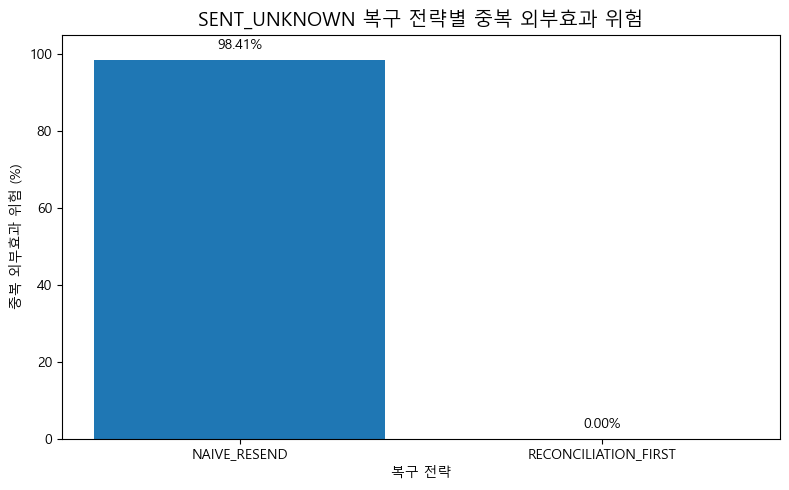

In [9]:
# 14. Recovery 전략별 중복 외부효과 위험 비교

strategy_plot_df = pd.DataFrame({
    "strategy": [
        "NAIVE_RESEND",
        "RECONCILIATION_FIRST"
    ],
    "duplicate_effect_risk": [
        recovery_test_df[
            "naive_duplicate_effect_risk"
        ].mean(),
        recovery_test_df[
            "reconciliation_duplicate_effect_risk"
        ].mean()
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    strategy_plot_df["strategy"],
    strategy_plot_df["duplicate_effect_risk"] * 100
)

plt.title(
    "SENT_UNKNOWN 복구 전략별 중복 외부효과 위험",
    fontsize=14
)

plt.ylabel("중복 외부효과 위험 (%)")
plt.xlabel("복구 전략")
plt.ylim(0, 105)

for bar, value in zip(
    bars,
    strategy_plot_df["duplicate_effect_risk"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [7]:
# 15. Recovery 전략 Paired 비교

from statsmodels.stats.contingency_tables import mcnemar

naive = recovery_test_df[
    "naive_duplicate_effect_risk"
].astype(int)

reconciliation = recovery_test_df[
    "reconciliation_duplicate_effect_risk"
].astype(int)

comparison_table = pd.crosstab(
    naive,
    reconciliation
)

display(comparison_table)


# 16. McNemar Exact Test

table = [
    [
        ((naive == 0) & (reconciliation == 0)).sum(),
        ((naive == 0) & (reconciliation == 1)).sum()
    ],
    [
        ((naive == 1) & (reconciliation == 0)).sum(),
        ((naive == 1) & (reconciliation == 1)).sum()
    ]
]

result = mcnemar(
    table,
    exact=True
)

print(f"McNemar statistic : {result.statistic}")
print(f"p-value           : {result.pvalue:.6g}")


# 17. 절대 위험 차이

naive_risk = naive.mean()
reconciliation_risk = reconciliation.mean()

risk_difference = (
    naive_risk
    - reconciliation_risk
)

relative_reduction = (
    risk_difference / naive_risk
    if naive_risk > 0
    else np.nan
)

print(
    f"NAIVE_RESEND 위험      : {naive_risk:.4%}"
)

print(
    f"RECONCILIATION 위험   : {reconciliation_risk:.4%}"
)

print(
    f"절대 위험 차이         : {risk_difference:.4%}"
)

print(
    f"상대 위험 감소         : {relative_reduction:.4%}"
)

reconciliation_duplicate_effect_risk,0
naive_duplicate_effect_risk,
0,1169
1,72241


McNemar statistic : 0.0
p-value           : 0
NAIVE_RESEND 위험      : 98.4076%
RECONCILIATION 위험   : 0.0000%
절대 위험 차이         : 98.4076%
상대 위험 감소         : 100.0000%


## 7. 검정 및 효과크기 해석

동일한 73,410개 Transaction에 두 Recovery 전략을 적용한 결과:

- `NAIVE_RESEND` 중복 외부효과 위험: **98.4076%**
- `RECONCILIATION_FIRST` 중복 외부효과 위험: **0.0000%**
- 절대 위험 차이: **98.4076%p**
- 상대 위험 감소: **100%**
- McNemar exact test: `p < 0.001`

단, 본 McNemar 검정은 일반적인 모집단 추론의 핵심 근거로 사용하지 않는다.

`RECONCILIATION_FIRST` 전략은 기존 Transaction 상태를 확인하기 전
새로운 외부 실행을 발생시키지 않도록 정의했기 때문에,
중복 외부효과 위험 0%는 해당 Runtime Policy의 구조적 결과이다.

따라서 본 분석의 핵심 실증 Evidence는 다음이다.

1. 실제 Ethereum Transaction 73,410건 모두 고유한 `transaction_hash`를 가졌다.
2. 모든 Transaction에서 `transaction_hash → receipt_status` 연결이 가능했다.
3. 기존 Transaction 중 72,241건(98.4076%)은 이미 성공 상태였다.
4. 따라서 실행 여부를 확인하지 않고 UNKNOWN 상태를 실패로 간주하여 재전송할 경우,
   이미 성공한 Transaction을 다시 실행하려는 위험이 존재한다.

결론적으로 `SENT_UNKNOWN`은 `FAILED`와 동일하게 처리해서는 안 된다.

## 8. FPG 설계 결론

DA-06 분석 결과 FPG Digital Asset Runtime은
`SENT_UNKNOWN → 즉시 RETRY` 구조를 허용해서는 안 된다.

필수 상태 전이는 다음과 같다.

`SUBMITTED`
→ `SENT_UNKNOWN`
→ `RECONCILING`
→ `FINALIZED / FAILED / RECONCILIATION_REQUIRED`

### Runtime Invariant

#### 1. Idempotency

동일 Business Request에는 하나의 `idempotency_key`를 부여한다.

동일 `idempotency_key`에 대해 새로운 Outbound Submission을
무조건 생성해서는 안 된다.

#### 2. External Reference Binding

외부 전송 후 생성된 식별자는 반드시 내부 요청과 연결한다.

`idempotency_key`
→ `external_transaction_id`
→ `execution_status`

Ethereum에서는 `transaction_hash`가
`external_transaction_id` 역할을 수행한다.

#### 3. SENT_UNKNOWN 처리

응답 유실 또는 Timeout이 발생했다고 해서
외부 실행 실패를 의미하지 않는다.

따라서:

`SENT_UNKNOWN != FAILED`

이어야 한다.

#### 4. Recovery First

`external_transaction_id`가 존재하면
새로운 외부 실행보다 기존 실행 조회를 우선한다.

조회 결과:

- 성공 확인 → `FINALIZED`
- 실패 확인 → `FAILED`
- 상태 확인 불가 → `RECONCILIATION_REQUIRED`

#### 5. Retry 조건

Retry는 단순 Timeout이 아니라
기존 실행의 Terminal Failure가 확인된 이후에만 검토한다.

새로운 Retry가 허용되는 경우에도
원 요청과의 lineage를 유지해야 한다.

## 10. 한계

본 데이터는 블록체인에 기록된 Ethereum Transaction 데이터이므로
실제 Gateway의 네트워크 Timeout, 응답 유실, Retry 요청 로그를 포함하지 않는다.

따라서 다음 항목은 본 분석에서 측정하지 않았다.

- 실제 SENT_UNKNOWN 발생률
- 실제 Retry 발생률
- 네트워크 장애 빈도
- Provider별 Recovery Latency
- 동일 Business Request의 실제 중복 제출률

본 실험은 실제 Transaction 결과를 이용하여
`응답을 알 수 없는 상황에서 기존 실행을 확인하지 않고 재전송하는 정책`
의 위험을 counterfactual 방식으로 검증하였다.

또한 원천 데이터에 Ethereum `nonce`가 없어
`from_address + nonce` 기반 중복 Transaction 검증은 수행하지 못했다.


## 11. 최종 요약

Ethereum Master Sample 73,410건을 분석한 결과:

- Transaction Hash 결측: **0건**
- Transaction Hash 중복: **0건**
- Hash 기반 실행 상태 복구 가능: **73,410건 / 100%**
- FINALIZED: **72,241건 / 98.4076%**
- FAILED: **1,169건 / 1.5924%**

Counterfactual SENT_UNKNOWN 상황에서
기존 실행 상태를 확인하지 않고 재전송한다고 가정할 경우,
98.4076%의 Transaction은 이미 성공 상태였다.

따라서 FPG Digital Asset Runtime의 핵심 Recovery 원칙은 다음과 같다.

**UNKNOWN ≠ FAILED**

**Retry Before Reconciliation 금지**

**Idempotency Key → External Transaction ID → Execution State**

**동일 요청 식별 → 기존 실행 조회 → 상태 복구 → Retry 판단**

DA-06은 이를 FPG의
Idempotency / SENT_UNKNOWN / Recovery Runtime Contract로 고정한다.